<a href="https://colab.research.google.com/github/jhuarancca/ChiefAIOfficerProgram/blob/main/CAIO_Entregable02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

In [2]:
!pip install rarfile

In [15]:
import gdown
import pandas as pd

df = pd.read_csv("ingresos_2017_2025_04.csv", encoding="latin-1")



/tmp/ipykernel_246/2254251627.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ingresos_2017_2025_04.csv", encoding="latin-1")


📊 Datos cargados: 2324679 empleados, 22 columnas


In [17]:
# FUNCIÓN PARA CARGAR ARCHIVO
print(f"📊 Datos cargados: {df.shape[0]} empleados, {df.shape[1]} columnas")

# Mostrar datos
df.tail()



📊 Datos cargados: 2324679 empleados, 22 columnas


,codi_vent,codi_clie,seri_vent,nume_vent,femi_vent,total_vent,totigv_vent,mon4_vent,mone_vent,esta_vent,...,CH_CODI_TURNO,CH_CODI_GARITA,plac_unid,CH_CODI_DEPA,cant_vent,prec_vent,subt_vent,um_vent,codi_prod,nomb_prod
2324674,B11000394603,9998,1,1,2017-09-09 10:36:52.690000000,3.0,0.457627,2.542373,S,R,...,1,6,CAM,15,1.0,3.0,3.0,3.0,77,PARQUEO ...
2324675,B11000394703,9998,1,1,2017-09-09 11:40:18.737000000,5.0,0.762712,4.237288,S,R,...,1,6,D4W874,15,1.0,5.0,5.0,3.0,77,PARQUEO ...
2324676,B11000394803,9998,1,1,2017-09-09 12:15:32.400000000,9.5,1.449152,8.050848,S,R,...,1,6,ANM365,15,40.0,9.5,9.5,1.0,95,Ingreso de HARINA - SC. ...
2324677,B11000394903,9998,1,1,2017-09-09 12:24:58.580000000,1.5,0.228814,1.271186,S,R,...,1,6,C2L925,15,1.0,1.5,1.5,3.0,77,PARQUEO ...
2324678,B11000395003,9998,1,1,2017-09-09 12:42:27.480000000,3.0,0.457627,2.542373,S,R,...,1,6,CAM,15,1.0,3.0,3.0,3.0,77,PARQUEO ...


In [21]:
print("\n" + "="*60)
print("📈 CARGA DE DATA - INGRESOS")
print("="*60)

# FUNCIÓN PARA CARGAR ARCHIVO
print(f"📊 Datos cargados: {df.shape[0]} empleados, {df.shape[1]} columnas")



📈 CARGA DE DATA - INGRESOS
📊 Datos cargados: 2324679 empleados, 22 columnas


In [26]:
print("\n" + "="*60)
print("📈 ANÁLISIS EXPLORATORIO DE DATOS")
print("="*60)

# Dimensiones y tipos de datos
print(f"📐 Dimensiones: {df.shape}")
print(f"🔤 Tipos de datos:\n{df.dtypes}")

print("\n" + "="*40)
print("👀 PRIMER VISTAZO A LOS DATOS")
print("="*40)

# Primer vistazo
print("Primeras 5 filas:")
print(df.head())

print("\nEstadísticas descriptivas:")
print(df.describe())

print("\n" + "="*40)
print("🔍 CALIDAD DE DATOS")
print("="*40)

 # Valores nulos
print("Valores nulos por columna:")
null_count = df.isnull().sum()
print(null_count)

# Mostrar columnas con valores nulos
if null_count.any():
    print(f"\n⚠️  Columnas con valores nulos: {list(null_count[null_count > 0].index)}")
else:
    print("✅ No hay valores nulos en el dataset")

# Duplicados
duplicates = df.duplicated().sum()
print(f"\n📝 Registros duplicados: {duplicates}")

if duplicates > 0:
    print("⚠️  Se recomienda limpiar los registros duplicados")
else:
    print("✅ No hay registros duplicados")




📈 ANÁLISIS EXPLORATORIO DE DATOS
📐 Dimensiones: (2324679, 22)
🔤 Tipos de datos:
codi_vent          object
codi_clie           int64
seri_vent           int64
nume_vent           int64
femi_vent          object
total_vent        float64
totigv_vent       float64
mon4_vent         float64
mone_vent          object
esta_vent          object
codi_vend           int64
CODI_TCOM           int64
CH_CODI_TURNO       int64
CH_CODI_GARITA      int64
plac_unid          object
CH_CODI_DEPA        int64
cant_vent         float64
prec_vent         float64
subt_vent         float64
um_vent           float64
codi_prod           int64
nomb_prod          object
dtype: object

👀 PRIMER VISTAZO A LOS DATOS
Primeras 5 filas:
      codi_vent  codi_clie  seri_vent  nume_vent  \
0  B11000395103       9998          1          1   
1  B11000395203       9998          1          1   
2  B11000395303       9998          1          1   
3  B11000395403       9998          1          1   
4  B11000395503       999


📊 ANÁLISIS DE OUTLIERS
Columnas numéricas encontradas: ['codi_clie', 'seri_vent', 'nume_vent', 'total_vent', 'totigv_vent', 'mon4_vent', 'codi_vend', 'CODI_TCOM', 'CH_CODI_TURNO', 'CH_CODI_GARITA', 'CH_CODI_DEPA', 'cant_vent', 'prec_vent', 'subt_vent', 'um_vent', 'codi_prod']


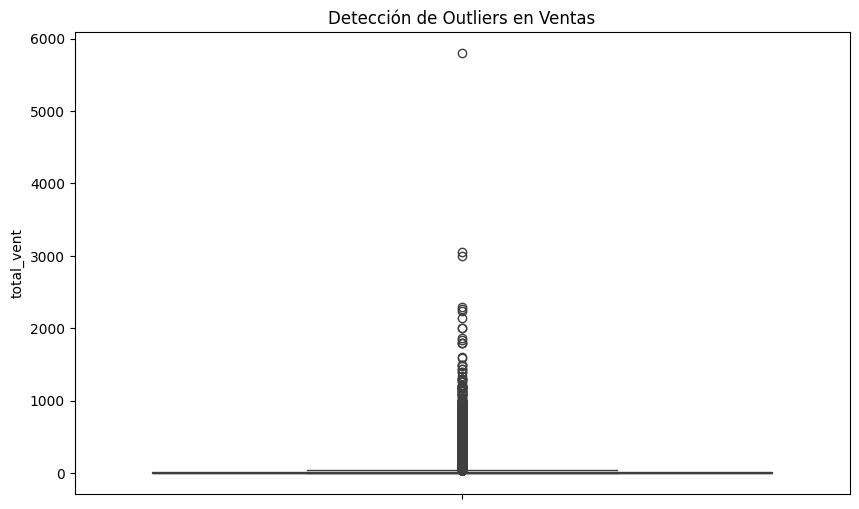


📊 Estadísticas de ventas:
   Mínimo: 0.04
   Máximo: 5800.00
   Mediana: 8.00
   Promedio: 23.25


In [31]:
print("\n" + "="*40)
print("📊 ANÁLISIS DE OUTLIERS")
print("="*40)

 # Identificar columnas numéricas para análisis de outliers
numeric_columns = df.select_dtypes(include=[np.number]).columns

if len(numeric_columns) > 0:
    print(f"Columnas numéricas encontradas: {list(numeric_columns)}")

    # Verificar si existe la columna 'ventas'
    if 'total_vent' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, y='total_vent')
        plt.title('Detección de Outliers en Ventas')
        plt.show()

        # Estadísticas adicionales de ventas
        print(f"\n📊 Estadísticas de ventas:")
        print(f"   Mínimo: {df['total_vent'].min():.2f}")
        print(f"   Máximo: {df['total_vent'].max():.2f}")
        print(f"   Mediana: {df['total_vent'].median():.2f}")
        print(f"   Promedio: {df['total_vent'].mean():.2f}")
    else:
        print("❌ No se encontró la columna 'ventas'")
        print("Columnas disponibles:", list(df.columns))

        # Mostrar boxplot de la primera columna numérica disponible
        primera_numerica = numeric_columns[0]
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, y=primera_numerica)
        plt.title(f'Detección de Outliers en {primera_numerica}')
        plt.show()

In [36]:
df.head()

,codi_vent,codi_clie,seri_vent,nume_vent,femi_vent,total_vent,totigv_vent,mon4_vent,mone_vent,esta_vent,...,CH_CODI_TURNO,CH_CODI_GARITA,plac_unid,CH_CODI_DEPA,cant_vent,prec_vent,subt_vent,um_vent,codi_prod,nomb_prod
0,B11000395103,9998,1,1,2017-09-09 12:59:32.007000000,6.0,0.915254,5.084746,S,R,...,1,6,D9X740,15,15.0,6.0,6.0,2.0,205,Ingreso de PINTURAS(LATEX O ESMALTE) ...
1,B11000395203,9998,1,1,2017-09-09 13:15:39,15.0,2.288135,12.711865,S,R,...,1,6,AHT885,15,200.0,15.0,15.0,2.0,39,Ingreso de GELATINAS ...
2,B11000395303,9998,1,1,2017-09-09 13:20:43.340000000,1.5,0.228814,1.271186,S,R,...,1,6,COMBI,15,1.0,1.5,1.5,3.0,77,PARQUEO ...
3,B11000395403,9998,1,1,2017-09-09 13:39:16.170000000,6.0,0.915254,5.084746,S,R,...,1,6,MOTO,15,6.0,1.0,6.0,3.0,87,TRANSBORDO DE PRODUCTOS ...
4,B11000395503,9998,1,1,2017-09-11 08:26:39.487000000,1.5,0.228814,1.271186,S,R,...,1,6,W3X895,15,1.0,1.5,1.5,3.0,77,PARQUEO ...


In [38]:
df['fechahora'] = pd.to_datetime(df['femi_vent'], format='mixed')

df['fecha'] = df['fechahora'].dt.date
df['hora'] = df['fechahora'].dt.time

In [39]:
df.head()

,codi_vent,codi_clie,seri_vent,nume_vent,femi_vent,total_vent,totigv_vent,mon4_vent,mone_vent,esta_vent,...,CH_CODI_DEPA,cant_vent,prec_vent,subt_vent,um_vent,codi_prod,nomb_prod,fechahora,fecha,hora
0,B11000395103,9998,1,1,2017-09-09 12:59:32.007000000,6.0,0.915254,5.084746,S,R,...,15,15.0,6.0,6.0,2.0,205,Ingreso de PINTURAS(LATEX O ESMALTE) ...,2017-09-09 12:59:32.007,2017-09-09,12:59:32.007000
1,B11000395203,9998,1,1,2017-09-09 13:15:39,15.0,2.288135,12.711865,S,R,...,15,200.0,15.0,15.0,2.0,39,Ingreso de GELATINAS ...,2017-09-09 13:15:39.000,2017-09-09,13:15:39
2,B11000395303,9998,1,1,2017-09-09 13:20:43.340000000,1.5,0.228814,1.271186,S,R,...,15,1.0,1.5,1.5,3.0,77,PARQUEO ...,2017-09-09 13:20:43.340,2017-09-09,13:20:43.340000
3,B11000395403,9998,1,1,2017-09-09 13:39:16.170000000,6.0,0.915254,5.084746,S,R,...,15,6.0,1.0,6.0,3.0,87,TRANSBORDO DE PRODUCTOS ...,2017-09-09 13:39:16.170,2017-09-09,13:39:16.170000
4,B11000395503,9998,1,1,2017-09-11 08:26:39.487000000,1.5,0.228814,1.271186,S,R,...,15,1.0,1.5,1.5,3.0,77,PARQUEO ...,2017-09-11 08:26:39.487,2017-09-11,08:26:39.487000


In [40]:
# EVOLUCIÓN TEMPORAL DE VENTAS
print("\n\n📅 EVOLUCIÓN TEMPORAL DE VENTAS")

# Primero, examinemos cómo se ven las fechas
print("🔍 Examinando formato de fechas...")
print("Primeras 5 fechas:", df['fecha'].head().tolist())
print("Tipo de dato actual:", df['fecha'].dtype)



📅 EVOLUCIÓN TEMPORAL DE VENTAS
🔍 Examinando formato de fechas...
Primeras 5 fechas: [datetime.date(2017, 9, 9), datetime.date(2017, 9, 9), datetime.date(2017, 9, 9), datetime.date(2017, 9, 9), datetime.date(2017, 9, 11)]
Tipo de dato actual: object




📅 EVOLUCIÓN TEMPORAL DE VENTAS
🔍 Examinando formato de fechas...
Primeras 5 fechas: [datetime.date(2017, 9, 9), datetime.date(2017, 9, 9), datetime.date(2017, 9, 9), datetime.date(2017, 9, 9), datetime.date(2017, 9, 11)]
Tipo de dato actual: object


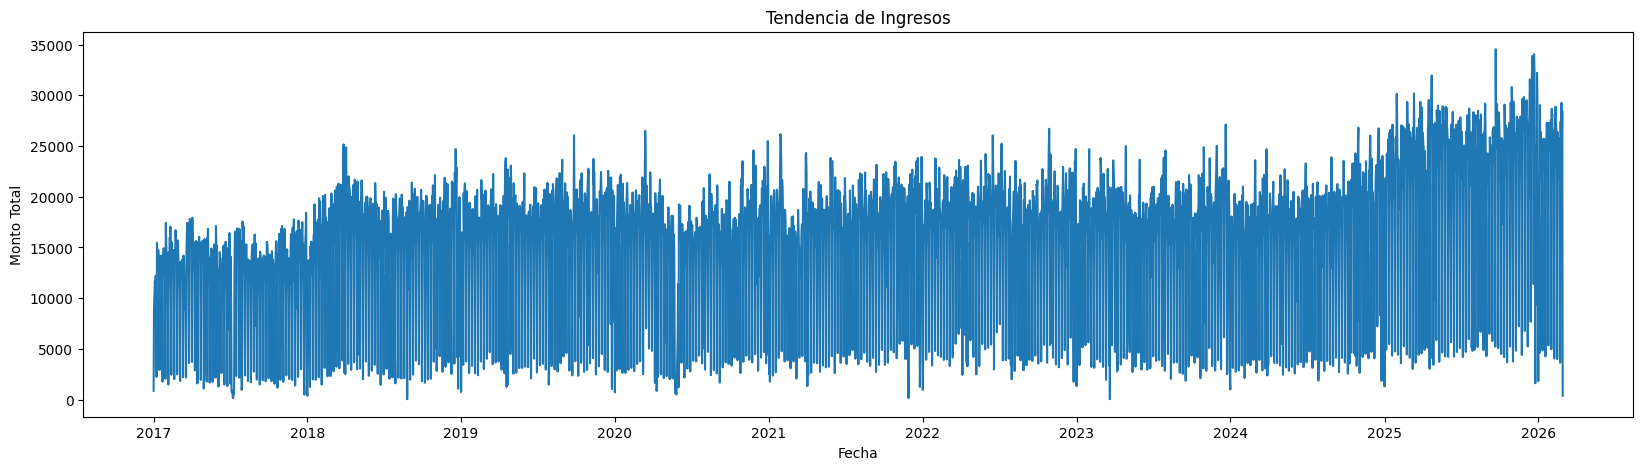

In [42]:
# EVOLUCIÓN TEMPORAL DE VENTAS
print("\n\n📅 EVOLUCIÓN TEMPORAL DE VENTAS")

# Primero, examinemos cómo se ven las fechas
print("🔍 Examinando formato de fechas...")
print("Primeras 5 fechas:", df['fecha'].head().tolist())
print("Tipo de dato actual:", df['fecha'].dtype)

df_tendencia = df.groupby('fecha')['total_vent'].sum()

plt.figure(figsize=(20,5))
plt.plot(df_tendencia.index, df_tendencia.values)
plt.xlabel('Fecha')
plt.ylabel('Monto Total')
plt.title('Tendencia de Ingresos')
#plt.xticks(rotation=45)
plt.show()

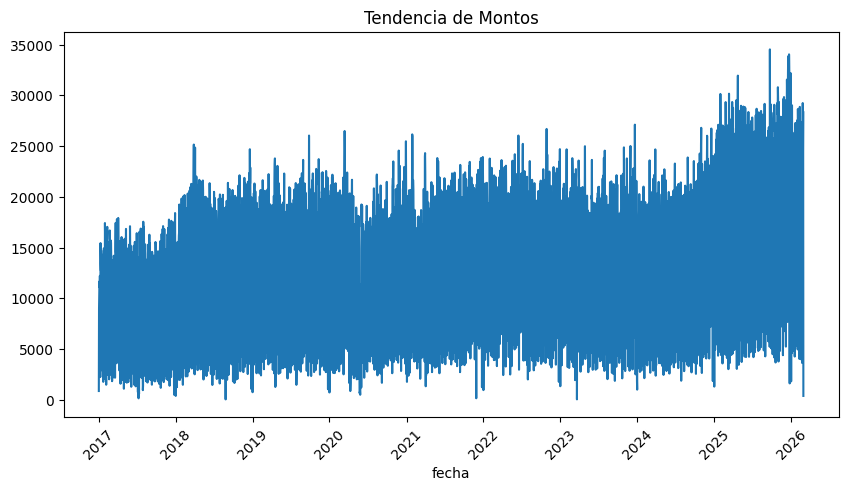

In [43]:
df.groupby('fecha')['total_vent'].sum().plot(figsize=(10,5), title='Tendencia de Montos')
plt.xticks(rotation=45)
plt.show()

In [53]:
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df['mes'] = df['fecha'].dt.month
df['anio'] = df['fecha'].dt.year
df['periodo'] = df['anio'].astype(str) + '-' + df['mes'].astype(str)

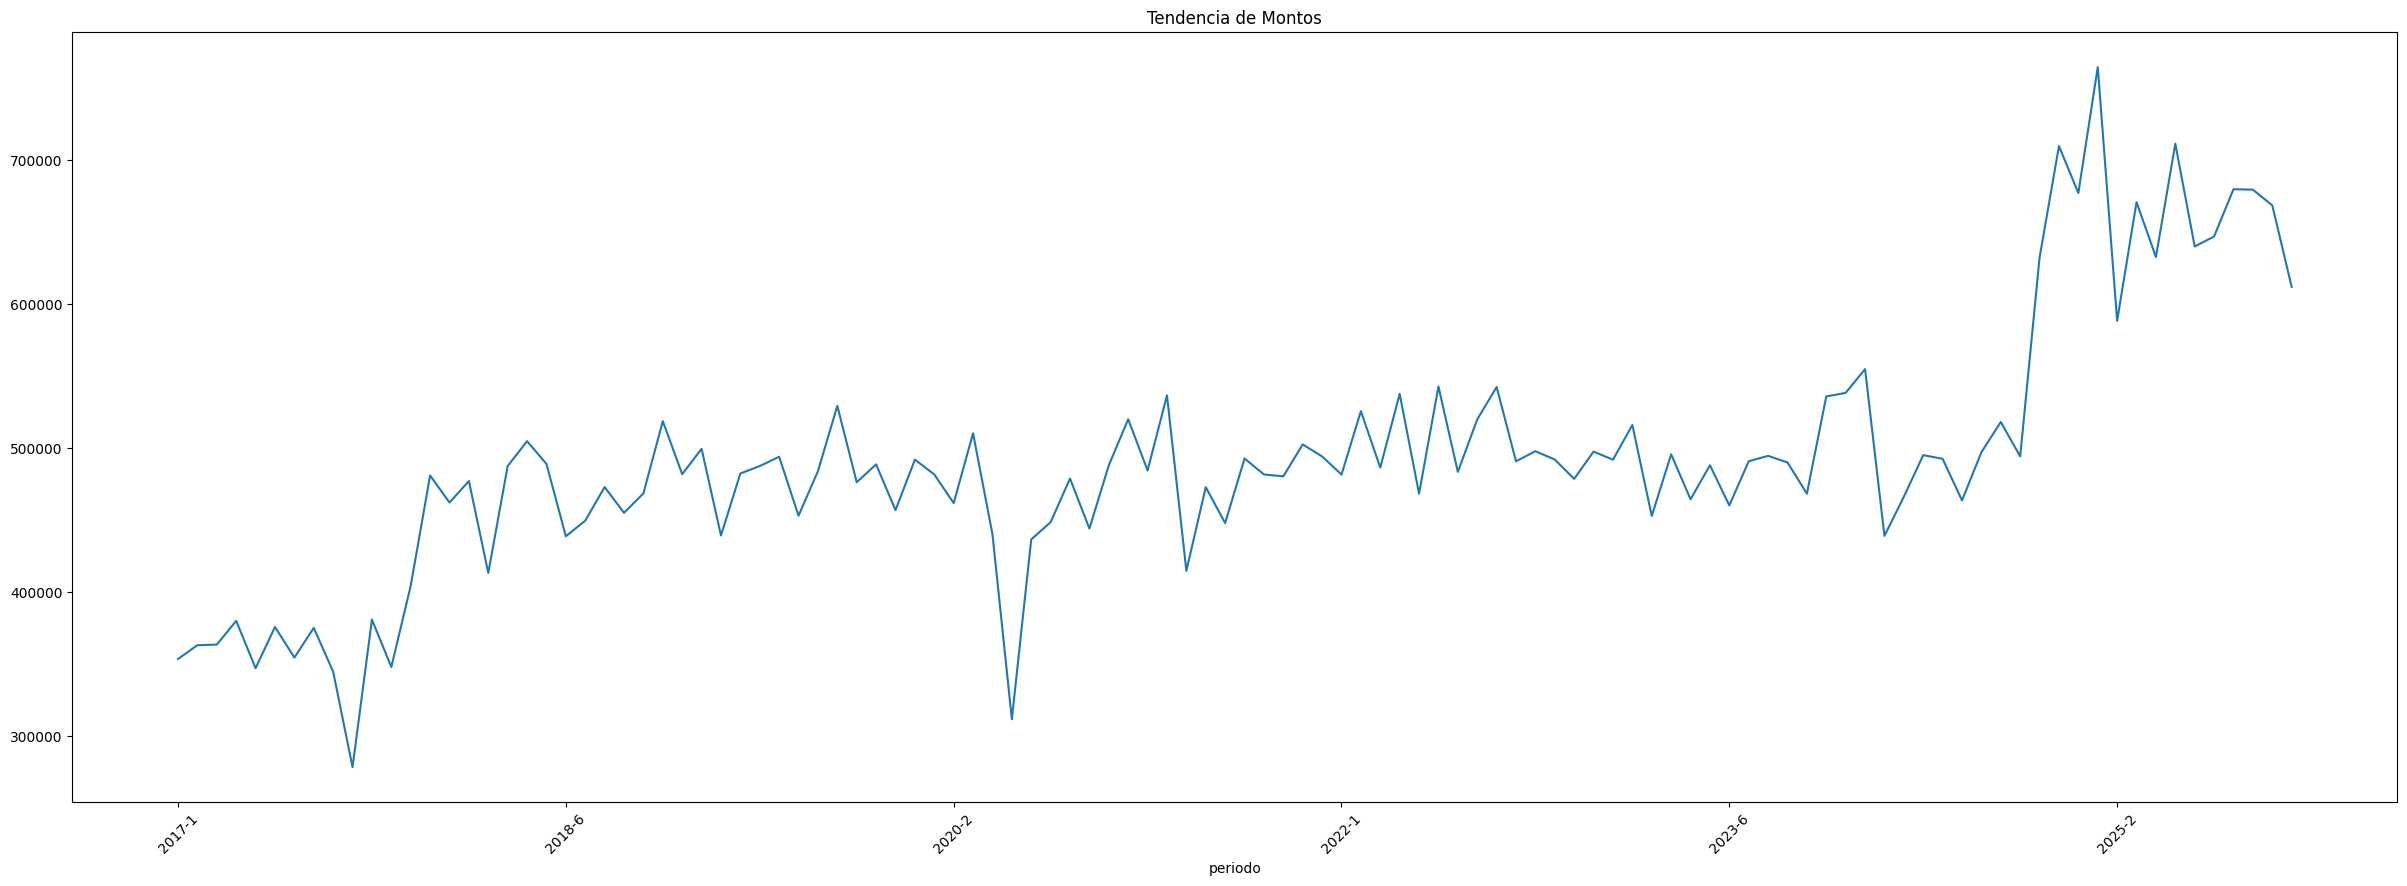

In [56]:
df.groupby('periodo')['total_vent'].sum().plot(figsize=(30,10), title='Tendencia de Montos')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# MATRIZ DE CORRELACIÓN CON TUS VARIABLES
print("\n" + "="*50)
print("🔗 MATRIZ DE CORRELACIÓN")
print("="*50)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

print(f"Variables numéricas encontradas: {list(numeric_cols)}")

if len(numeric_cols) > 1:
    # Calcular matriz de correlación
    corr_matrix = df[numeric_cols].corr()

    # Crear el heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix,
                annot=True,
                cmap='coolwarm',
                center=0,
                fmt='.2f',
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8})

    plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Análisis interpretativo de correlaciones
    print("\n📊 INTERPRETACIÓN DE CORRELACIONES:")

    # Encontrar correlaciones fuertes (positivas y negativas)
    strong_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.5:  # Correlación fuerte
                strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_value))

    if strong_corr:
        print("🔍 Correlaciones fuertes encontradas:")
        for var1, var2, corr in strong_corr:
            direction = "positiva" if corr > 0 else "negativa"
            print(f"   • {var1} ↔ {var2}: {corr:.2f} ({direction})")
    else:
        print("   No se encontraron correlaciones fuertes (|r| > 0.5)")

    # Correlación específica con 'monto' (si existe)
    if 'monto' in numeric_cols:
        print(f"\n💰 CORRELACIONES CON MONTO:")
        monto_correlations = corr_matrix['monto'].sort_values(ascending=False)
        for var, corr in monto_correlations.items():
            if var != 'monto':  # Excluir correlación consigo mismo
                strength = "fuerte" if abs(corr) > 0.5 else "moderada" if abs(corr) > 0.3 else "débil"
                direction = "positiva" if corr > 0 else "negativa"
                print(f"   • {var}: {corr:.2f} ({strength}, {direction})")

else:
    print("❌ No hay suficientes variables numéricas para calcular correlaciones")
    print(f"   Variables numéricas encontradas: {len(numeric_cols)}")

    # Mostrar variables disponibles para contexto
    print(f"\n📋 TODAS LAS VARIABLES DISPONIBLES:")
    for col in df.columns:
        dtype = df[col].dtype
        print(f"   • {col}: {dtype}")


🔗 MATRIZ DE CORRELACIÓN
Variables numéricas encontradas: ['monto']
❌ No hay suficientes variables numéricas para calcular correlaciones
   Variables numéricas encontradas: 1

📋 TODAS LAS VARIABLES DISPONIBLES:
   • vendedor: object
   • monto: float64
   • fecha: datetime64[ns]
   • tienda: object
   • region: object
